<!-- @format -->

# Adult Income Prediction – Deep Learning Pipeline

Notebook này xây dựng pipeline Deep Learning **hoàn chỉnh và độc lập** cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Load dữ liệu
2. Tiền xử lý riêng cho DL (LabelEncoder, StandardScaler, encode target 0/1, tách train/val/test)
3. Tạo Dataset & DataLoader (PyTorch)
4. Xây dựng mô hình MLP
5. Huấn luyện end-to-end với Early Stopping
6. Đánh giá trên test set
7. Trực quan hóa learning curves


<!-- @format -->

## 4.1. Import & Setup


In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch

import modules.deep_learning as dl

# Kiểm tra GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu126


<!-- @format -->

## 4.2. Load dữ liệu


In [13]:
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = pd.read_csv(url)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


<!-- @format -->

## 4.3. Tiền xử lý cho Deep Learning

Pipeline tiền xử lý riêng cho DL bao gồm:

- Chuẩn hóa `?` → `NaN`
- Loại bỏ cột dư thừa (`education`, `fnlwgt`)
- Encode target `income` → `0/1`
- Tách **train / val / test** (stratified) – DL cần val set để theo dõi quá trình training
- Impute missing cho categorical bằng most_frequent
- **LabelEncoder** cho categorical (thay vì OHE – phù hợp hơn với neural network)
- **StandardScaler** cho numerical
- Chuyển tất cả sang `float32` / `int64` numpy array


In [14]:
prep = dl.preprocess_for_dl(
    df,
    target_col='income',
    cols_to_drop=['education', 'fnlwgt'],
    cat_impute_strategy='most_frequent',
    test_size=0.2,
    val_size=0.15,
    random_state=42,
)

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

Train: 33212  |  Val: 5861  |  Test: 9769
Input dimension: 12
Target distribution (train): [25265  7947]


<!-- @format -->

### Kiểm tra dữ liệu sau tiền xử lý


In [15]:
print("X_train shape:", prep['X_train'].shape, "| dtype:", prep['X_train'].dtype)
print("X_val shape  :", prep['X_val'].shape)
print("X_test shape :", prep['X_test'].shape)
print("\ny_train distribution:", np.bincount(prep['y_train']))
print("y_val distribution  :", np.bincount(prep['y_val']))
print("y_test distribution :", np.bincount(prep['y_test']))

X_train shape: (33212, 12) | dtype: float32
X_val shape  : (5861, 12)
X_test shape : (9769, 12)

y_train distribution: [25265  7947]
y_val distribution  : [4459 1402]
y_test distribution : [7431 2338]


<!-- @format -->

## 4.4. Tạo DataLoader

Chuyển dữ liệu numpy sang `torch.utils.data.DataLoader` để phục vụ training theo batch.


In [16]:
train_loader, val_loader, test_loader = dl.create_dataloaders(
    prep, batch_size=256
)

DataLoaders created  |  batch_size=256
  Train batches: 130  |  Val batches: 23  |  Test batches: 39


<!-- @format -->

## 4.5. Xây dựng mô hình MLP

Mô hình MLP (Multi-Layer Perceptron) gồm:

- Các hidden layer với **BatchNorm → ReLU → Dropout**
- Output layer: 2 units (binary classification)
- Loss: **CrossEntropyLoss có class weights** để xử lý mất cân bằng lớp


In [17]:
model = dl.MLP(
    input_dim=prep['input_dim'],
    hidden_dims=[128, 64],
    dropout=0.3,
)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=12, out_features=128, bias=True)
    (bn_0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.3, inplace=False)
    (linear_1): Linear(in_features=128, out_features=64, bias=True)
    (bn_1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.3, inplace=False)
    (output): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 10,434


<!-- @format -->

## 4.6. Huấn luyện mô hình

Sử dụng:

- **Adam** optimizer với weight decay (L2 regularization)
- **ReduceLROnPlateau** scheduler – tự giảm learning rate khi val_loss không giảm
- **Early Stopping** – dừng sớm nếu val_loss không cải thiện sau `patience` epoch
- **Weighted CrossEntropy** – cân bằng loss giữa hai class


In [18]:
history = dl.train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    device=device,
)

Training on cuda  |  epochs=50  |  lr=0.001  |  patience=10
----------------------------------------------------------------------
Epoch   1/50  |  train_loss=0.5002  train_acc=0.7254  |  val_loss=0.4155  val_acc=0.7743 *
Epoch   2/50  |  train_loss=0.4353  train_acc=0.7747  |  val_loss=0.4029  val_acc=0.7705 *
Epoch   3/50  |  train_loss=0.4237  train_acc=0.7800  |  val_loss=0.3982  val_acc=0.7845 *
Epoch   4/50  |  train_loss=0.4148  train_acc=0.7847  |  val_loss=0.3968  val_acc=0.7756 *
Epoch   5/50  |  train_loss=0.4117  train_acc=0.7866  |  val_loss=0.3901  val_acc=0.7983 *
Epoch   6/50  |  train_loss=0.4071  train_acc=0.7883  |  val_loss=0.3891  val_acc=0.7951 *
Epoch   7/50  |  train_loss=0.4056  train_acc=0.7875  |  val_loss=0.3865  val_acc=0.7881 *
Epoch  10/50  |  train_loss=0.4006  train_acc=0.7889  |  val_loss=0.3893  val_acc=0.8178
Epoch  11/50  |  train_loss=0.3987  train_acc=0.7913  |  val_loss=0.3861  val_acc=0.7983 *
Epoch  12/50  |  train_loss=0.3960  train_acc=0.7916

<!-- @format -->

## 4.7. Learning Curves

Trực quan hóa loss và accuracy qua các epoch để kiểm tra overfitting / underfitting.


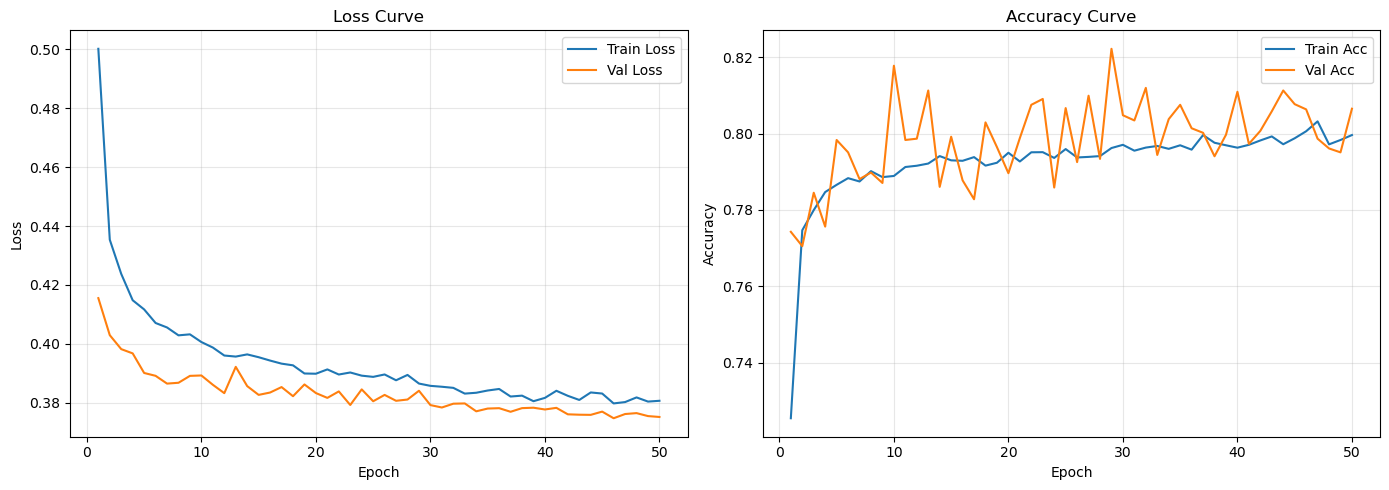

In [19]:
dl.plot_learning_curves(history)

<!-- @format -->

## 4.8. Đánh giá trên Test Set

Đánh giá mô hình trên tập test bằng các chỉ số: accuracy, precision, recall, F1-score, và confusion matrix.


=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.78      0.86      7431
        >50K       0.55      0.87      0.68      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.80      0.81      9769

Summary: {'accuracy': 0.8, 'precision': 0.5521, 'recall': 0.87, 'f1_score': 0.6755}


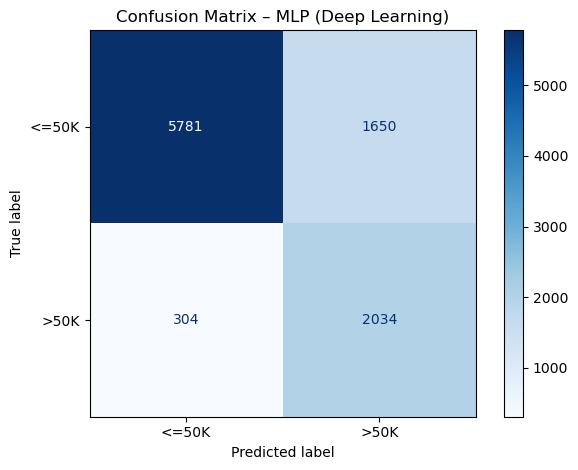

In [20]:
metrics, y_true, y_pred, y_proba = dl.evaluate_model(model, test_loader, device=device)

<!-- @format -->

## 4.9. Tổng kết

Pipeline Deep Learning đã hoàn thành với các bước:

| Bước           | Mô tả                                                                                     |
| -------------- | ----------------------------------------------------------------------------------------- |
| Tiền xử lý     | Impute missing, LabelEncoder (categorical), StandardScaler (numerical), encode target 0/1 |
| Train/Val/Test | 68% / 12% / 20% (stratified)                                                              |
| Mô hình        | MLP – 2 hidden layers [128, 64] + BatchNorm + Dropout                                     |
| Huấn luyện     | Adam + ReduceLROnPlateau + Early Stopping + Weighted CrossEntropy                         |
| Đánh giá       | Accuracy, Precision, Recall, F1-score, Confusion Matrix                                   |


<!-- @format -->

## 4.10. So sánh nhiều kiến trúc MLP

Để tìm cấu hình tốt nhất, ta thử nghiệm **nhiều kiến trúc** khác nhau:

- Thay đổi số lượng và kích thước hidden layers
- Thay đổi tỷ lệ dropout

Mỗi cấu hình được huấn luyện với cùng hyperparameters (lr, epochs, patience) và đánh giá trên **validation set** (để chọn mô hình) và **test set** (để báo cáo kết quả cuối).


In [21]:
# Reload module nếu đã sửa
import importlib
importlib.reload(dl)

# Chạy so sánh nhiều cấu hình
results = dl.compare_architectures(
    prep,
    configs=None,   # Dùng bộ configs mặc định (7 cấu hình)
    epochs=50,
    patience=10,
    device=device,
    batch_size=256,
)

DataLoaders created  |  batch_size=256
  Train batches: 130  |  Val batches: 23  |  Test batches: 39

[1/7]  Config: Small [64]
Parameters: 1,090
Training on cuda  |  epochs=50  |  lr=0.001  |  patience=10
----------------------------------------------------------------------
Epoch   1/50  |  train_loss=0.5739  train_acc=0.6782  |  val_loss=0.4815  val_acc=0.7154 *
Epoch   2/50  |  train_loss=0.4712  train_acc=0.7564  |  val_loss=0.4259  val_acc=0.7739 *
Epoch   3/50  |  train_loss=0.4390  train_acc=0.7747  |  val_loss=0.4039  val_acc=0.7922 *
Epoch   4/50  |  train_loss=0.4211  train_acc=0.7866  |  val_loss=0.4010  val_acc=0.7828 *
Epoch   5/50  |  train_loss=0.4203  train_acc=0.7869  |  val_loss=0.3970  val_acc=0.7848 *
Epoch   6/50  |  train_loss=0.4120  train_acc=0.7896  |  val_loss=0.3954  val_acc=0.7852 *
Epoch   7/50  |  train_loss=0.4106  train_acc=0.7894  |  val_loss=0.3918  val_acc=0.8011 *
Epoch  10/50  |  train_loss=0.4092  train_acc=0.7897  |  val_loss=0.3942  val_acc=0.81

<!-- @format -->

### Bảng so sánh kết quả


In [22]:
# Bảng so sánh
comparison_df = dl.show_comparison_table(results)
comparison_df.style.highlight_max(
    subset=["Val F1", "Test F1", "Test Acc"], color="lightgreen"
)

,Config,Params,Val Acc,Val F1,Test Acc,Test F1,Test Prec,Test Recall
0,Small [64],"1,090",0.800500,0.678600,0.795900,0.670600,0.546300,0.868300
1,"Medium [128, 64]","10,434",0.807200,0.684500,0.801300,0.677000,0.554100,0.870000
2,"Large [256, 128, 64]","45,506",0.809200,0.686800,0.802700,0.678800,0.556100,0.870800
3,"Deep [128, 64, 32]","12,514",0.795400,0.675200,0.787000,0.663900,0.533400,0.879000
4,"Wide [256, 128]","37,250",0.803800,0.683200,0.796600,0.673400,0.546900,0.876000
5,"Dropout-low [128, 64]","10,434",0.808200,0.686200,0.800700,0.674900,0.553500,0.864400
6,"Dropout-high [128, 64]","10,434",0.801600,0.678600,0.797100,0.672800,0.547800,0.871700


<!-- @format -->

### Biểu đồ so sánh & chọn mô hình tốt nhất


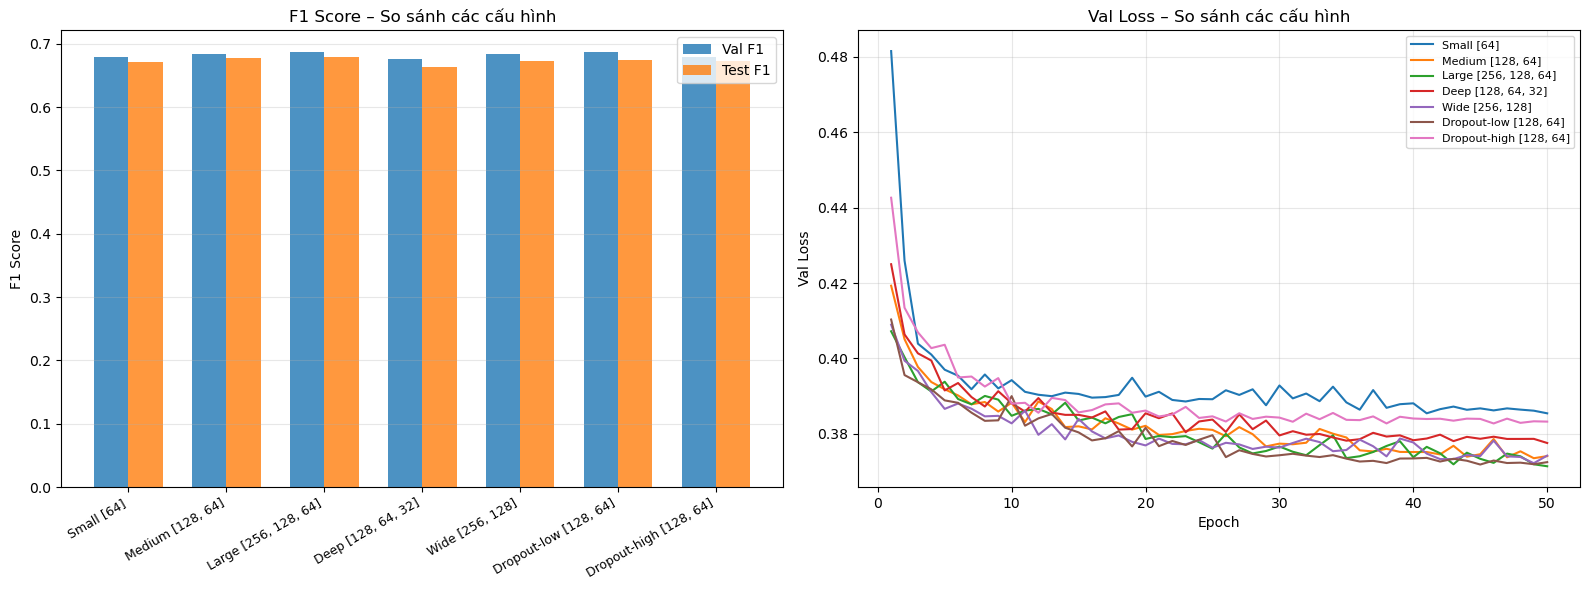


★ Cấu hình tốt nhất (theo Val F1): Large [256, 128, 64]  (val_f1=0.6868, test_f1=0.6788)


In [23]:
# Biểu đồ so sánh + chọn cấu hình tốt nhất
best = dl.plot_comparison(results)

★ Mô hình tốt nhất: Large [256, 128, 64]
  Hidden dims: [256, 128, 64]
  Dropout: 0.3

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.78      0.86      7431
        >50K       0.56      0.87      0.68      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.83      0.77      9769
weighted avg       0.86      0.80      0.81      9769

Summary: {'accuracy': 0.8027, 'precision': 0.5561, 'recall': 0.8708, 'f1_score': 0.6788}


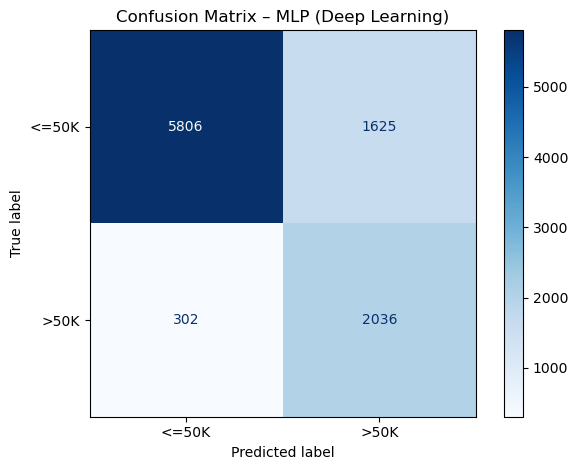

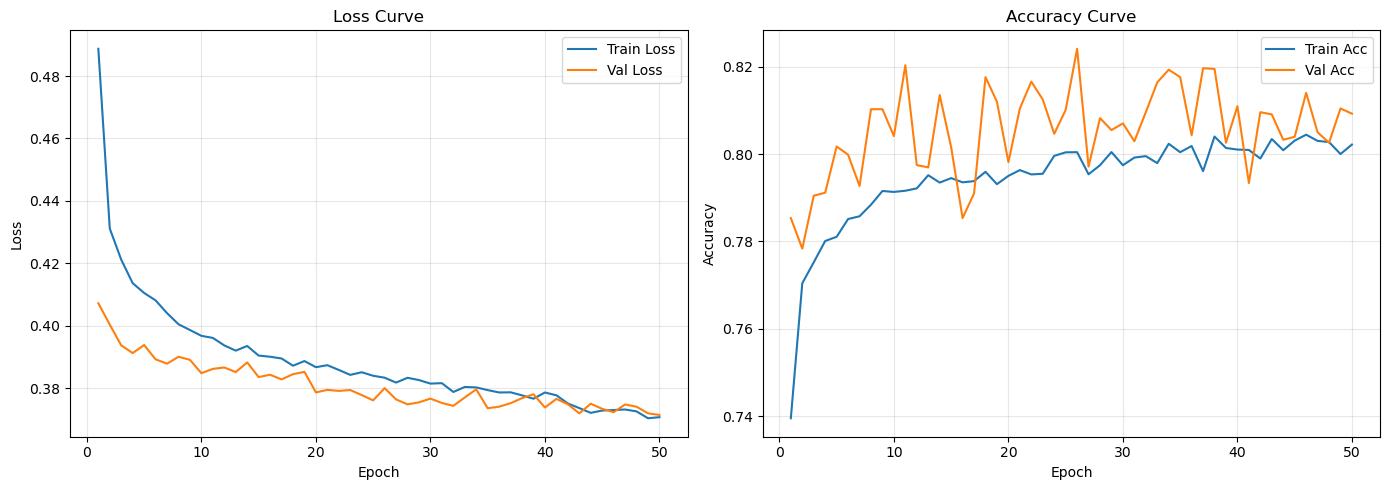

In [24]:
# Đánh giá chi tiết mô hình tốt nhất trên test set
print(f"★ Mô hình tốt nhất: {best['name']}")
print(f"  Hidden dims: {best['config']['hidden_dims']}")
print(f"  Dropout: {best['config']['dropout']}")
print()

best_model = best["model"]
metrics_best, y_true_best, y_pred_best, y_proba_best = dl.evaluate_model(
    best_model, test_loader, device=device
)

# Vẽ learning curve của mô hình tốt nhất
dl.plot_learning_curves(best["history"])